<a href="https://colab.research.google.com/github/KartikMantri/U-Kan-repo/blob/main/DualDecoder_KANbottleneck_REFUGE_week6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dual-Decoder U-Net **with a KAN Bottleneck** — 2-pipeline Optic Disc & Cup on REFUGE

**What this is.** The exact **dual-decoder Y-Net** from your `DualDecoder_UNet_REFUGE`
run — one shared conv encoder feeding **two parallel decoders** (a DISC head `[bg,disc]`
and a CUP head `[bg,cup]`) — but the plain conv **bottleneck is replaced by the tokenized
KAN bottleneck** from your U-KAN notebook (efficient-KAN: base-SiLU + cubic B-spline).

Everything else is kept **identical to the Y-Net** so the comparison is clean — only the
bottleneck changed (conv → KAN):

- Two heads are **not a partition**: `disc = (mask>0)` (whole disc = rim+cup), `cup = (mask==2)`. Cup is foreground in both (anatomically cup ⊆ disc).
- Joint loss = `Loss(disc) + Loss(cup)`, each head = CE + Dice (+ Focal-Tversky to push cup recall).
- **DISC and CUP pipelines are reported SEPARATELY** for train / val / test (your explicit ask).
- Best checkpoint chosen on **val mean foreground Dice = (disc_fg + cup_fg)/2**.
- A final **3-class fusion** cell (`cup ⊆ disc`) reports BOTH the whole-disc+cup mean and the clinical **rim+cup** mean vs the 0.90 target.

### How to run
- **Kaggle:** *+ Add Data* → `glaucoma-datasets` (arnavjain1) → Accelerator = GPU, Internet = On → *Run All*.
- **Colab:** Runtime → GPU → run CELL 1B (upload `kaggle.json`) → *Run All*.

> Only CELL 2 (CONFIG) may need editing. `BOTT_DIM` / `KAN_DEPTH` control the KAN bottleneck size.

In [1]:
# ==== CELL 1 — Environment setup & imports ====
import os, sys, glob, math, random, time, warnings, json
warnings.filterwarnings("ignore")

import numpy as np
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

# Albumentations = fast image+mask augmentation. Pre-installed on Kaggle; install if missing.
try:
    import albumentations as A
    from albumentations.pytorch import ToTensorV2
except Exception:
    os.system("pip install -q albumentations")
    import albumentations as A
    from albumentations.pytorch import ToTensorV2

from scipy import ndimage  # connected components + hole filling for post-processing

# ---- Reproducibility: fix every RNG so runs are comparable ----
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch:", torch.__version__, "| Albumentations:", A.__version__, "| Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.11.0+cu128 | Albumentations: 2.0.8 | Device: cuda
GPU: Tesla T4


In [2]:
# ==== CELL 1B — (GOOGLE COLAB ONLY) Download the Kaggle datasets ====
# The bundle "arnavjain1/glaucoma-datasets" contains ALL THREE datasets: G1020, ORIGA, REFUGE.
# On KAGGLE: skip this cell and use "+ Add Data" instead.  On your LAPTOP: skip it and
# point DATASET_ROOT at your local folder in CELL 2.  This cell auto-skips off Colab.
import os, sys
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    os.system("pip install -q kaggle")
    from google.colab import files
    print("Please upload your kaggle.json ...")
    files.upload()
    os.makedirs("/root/.kaggle", exist_ok=True)
    os.system("cp /content/kaggle.json /root/.kaggle/kaggle.json")
    os.system("chmod 600 /root/.kaggle/kaggle.json")
    os.makedirs("/content/glaucoma-datasets", exist_ok=True)
    os.system("kaggle datasets download -d arnavjain1/glaucoma-datasets "
              "-p /content/glaucoma-datasets --unzip")
    print("\nDownloaded. Top-level contents (expect G1020 / ORIGA / REFUGE):")
    print(sorted(os.listdir("/content/glaucoma-datasets")))
else:
    print("Not running on Colab -> skipping Kaggle download.")
    print("Kaggle: use '+ Add Data'.  Laptop: set CFG.DATASET_ROOT to your local folder.")

Please upload your kaggle.json ...


Saving kaggle.json to kaggle.json

Downloaded. Top-level contents (expect G1020 / ORIGA / REFUGE):
['G1020', 'ORIGA', 'REFUGE', 'models']


In [3]:
# ==== CELL 2 — CONFIG (the only cell you may need to edit) ====
class CFG:
    # ---------- Data ----------
    if os.path.isdir("/content/glaucoma-datasets"):
        DATASET_ROOT = "/content/glaucoma-datasets"       # Google Colab (CELL 1B)
    elif os.path.isdir("/kaggle/input"):
        DATASET_ROOT = "/kaggle/input"                    # Kaggle ("+ Add Data")
    else:
        DATASET_ROOT = "data"                             # laptop/VSCode
    DATASET_NAME = "REFUGE"
    USE_CROPPED  = True          # prefer pre-cropped ROI folders (best for cup Dice)
    IMG_SIZE     = 256           # 256 = matches your Y-Net Run-1 (fair conv-vs-KAN compare) | 384 = more cup detail
    NUM_CLASSES  = 3             # GT: 0=bg, 1=disc(rim), 2=cup  (heads are derived from this)

    # ---------- KAN bottleneck ----------
    BOTT_DIM   = 512             # channel width of the tokenized KAN bottleneck
    KAN_DEPTH  = 2               # number of residual KANBlocks in the bottleneck
    DROP_PATH  = 0.0

    # ---------- Training ----------
    BATCH_SIZE   = 8
    ACCUM_STEPS  = 2             # effective batch = 8*2 = 16
    EPOCHS       = 120
    PATIENCE     = 25
    LR           = 1e-3
    WEIGHT_DECAY = 1e-4
    NUM_WORKERS  = 2
    USE_AMP      = True

    # ---------- Per-head loss = W_CE*CE + W_DICE*Dice + W_FT*FocalTversky ----------
    W_CE   = 0.4
    W_DICE = 0.3
    W_FT   = 0.3
    # binary heads -> weights are [bg, fg]; upweight the foreground a little.
    DISC_CLASS_WEIGHTS = [1.0, 1.0]
    CUP_CLASS_WEIGHTS  = [1.0, 1.5]   # cup is the bottleneck class
    TVERSKY_ALPHA = 0.3   # FP weight
    TVERSKY_BETA  = 0.7   # FN weight (>alpha => rewards recall => fixes cup under-seg)
    TVERSKY_GAMMA = 0.75  # focal exponent

    # ---------- Inference ----------
    USE_TTA      = True
    USE_POSTPROC = True

    # ---------- Output ----------
    OUT_DIR   = "/kaggle/working" if os.path.isdir("/kaggle") else "."
    CKPT_PATH = os.path.join(OUT_DIR, "kan_ynet_refuge_best.pth")

cfg = CFG()
os.makedirs(cfg.OUT_DIR, exist_ok=True)
print(f"Image size = {cfg.IMG_SIZE} | eff.batch = {cfg.BATCH_SIZE*cfg.ACCUM_STEPS} | "
      f"KAN bottleneck: dim={cfg.BOTT_DIM}, depth={cfg.KAN_DEPTH}")

Image size = 256 | eff.batch = 16 | KAN bottleneck: dim=512, depth=2


In [4]:
# ==== CELL 3 — Auto-discover REFUGE image/mask folders & build train/val/test lists ====
IMG_KEYS  = (["Images_Cropped","images_cropped"] if cfg.USE_CROPPED else []) + ["Images","images","Images_Square","img"]
MASK_KEYS = (["Masks_Cropped","masks_cropped"] if cfg.USE_CROPPED else []) + ["Masks","masks","Masks_Square"]
EXTS = ("*.jpg","*.jpeg","*.png","*.bmp","*.tif","*.tiff")

def list_images(d):
    fs = []
    for e in EXTS: fs += glob.glob(os.path.join(d, e))
    return sorted(fs)

def find_dataset_dirs(root, name):
    triples = []
    for dirpath, dirnames, _ in os.walk(root):
        if name.lower() not in dirpath.lower():
            continue
        if os.path.basename(dirpath) in IMG_KEYS and len(list_images(dirpath)) > 0:
            parent = os.path.dirname(dirpath)
            mask_dir = next((os.path.join(parent, mk) for mk in MASK_KEYS
                             if os.path.isdir(os.path.join(parent, mk))), None)
            if mask_dir is None:
                gp = os.path.dirname(parent)
                mask_dir = next((os.path.join(gp, mk) for mk in MASK_KEYS
                                 if os.path.isdir(os.path.join(gp, mk))), None)
            if mask_dir:
                low = dirpath.lower()
                split = ("train" if "train" in low else
                         "val"   if ("val" in low or "valid" in low) else
                         "test"  if "test" in low else "all")
                triples.append((split, dirpath, mask_dir))
    return triples

triples = find_dataset_dirs(cfg.DATASET_ROOT, cfg.DATASET_NAME)
print("Discovered image/mask folders:")
for s,i,m in triples:
    print(f"  [{s:5s}] {len(list_images(i)):4d} imgs | {i}\n           masks | {m}")

def build_pairs(img_dir, mask_dir):
    masks = {}
    for p in list_images(mask_dir):
        masks.setdefault(os.path.splitext(os.path.basename(p))[0], p)
    pairs = []
    for ip in list_images(img_dir):
        stem = os.path.splitext(os.path.basename(ip))[0]
        if stem in masks:
            pairs.append((ip, masks[stem]))
    return pairs

split_pairs = {"train": [], "val": [], "test": []}
all_pairs = []
for s,i,m in triples:
    pr = build_pairs(i, m)
    all_pairs += pr
    if s in split_pairs:
        split_pairs[s] += pr

if min(len(v) for v in split_pairs.values()) == 0:
    print("\n[info] Official train/val/test folders not all found -> deterministic 70/15/15 split.")
    uniq = sorted(set(all_pairs))
    random.Random(SEED).shuffle(uniq)
    n = len(uniq); ntr = int(0.70*n); nva = int(0.15*n)
    split_pairs = {"train": uniq[:ntr], "val": uniq[ntr:ntr+nva], "test": uniq[ntr+nva:]}

print("\nFinal split sizes ->", {k: len(v) for k,v in split_pairs.items()})
assert len(split_pairs["train"]) > 0, "No training pairs found! Check DATASET_ROOT / USE_CROPPED in CELL 2."

Discovered image/mask folders:
  [train]  400 imgs | /content/glaucoma-datasets/REFUGE/train/Images
           masks | /content/glaucoma-datasets/REFUGE/train/Masks_Cropped
  [train]  400 imgs | /content/glaucoma-datasets/REFUGE/train/Images_Cropped
           masks | /content/glaucoma-datasets/REFUGE/train/Masks_Cropped
  [test ]  400 imgs | /content/glaucoma-datasets/REFUGE/test/Images
           masks | /content/glaucoma-datasets/REFUGE/test/Masks_Cropped
  [test ]  400 imgs | /content/glaucoma-datasets/REFUGE/test/Images_Cropped
           masks | /content/glaucoma-datasets/REFUGE/test/Masks_Cropped
  [all  ] 1200 imgs | /content/glaucoma-datasets/REFUGE/Images_Square
           masks | /content/glaucoma-datasets/REFUGE/Masks_Square
  [val  ]  400 imgs | /content/glaucoma-datasets/REFUGE/val/Images
           masks | /content/glaucoma-datasets/REFUGE/val/Masks_Cropped
  [val  ]  400 imgs | /content/glaucoma-datasets/REFUGE/val/Images_Cropped
           masks | /content/glaucoma-dat

In [5]:
# ==== CELL 4 — Detect mask encoding & remap to {0:bg, 1:disc, 2:cup} ====
def _read_gray(path):
    m = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if m is None: return None
    if m.ndim == 3: m = m[..., 0]
    return m

def sample_unique_values(pairs, k=40):
    vals = set()
    for _, mp in pairs[:k]:
        m = _read_gray(mp)
        if m is not None: vals |= set(np.unique(m).tolist())
    return sorted(vals)

uvals = sample_unique_values(split_pairs["train"])
print("Sampled unique mask pixel values:", uvals)

def remap_mask(m):
    """Return a HxW uint8 mask with values in {0=bg, 1=disc, 2=cup}."""
    if m.ndim == 3: m = m[..., 0]
    u = set(np.unique(m).tolist())
    out = np.zeros(m.shape, dtype=np.uint8)
    if u <= {0, 1, 2}:
        out = m.astype(np.uint8)
    elif u <= {0, 128, 255} or 128 in u:
        out[m == 255] = 0
        out[(m > 0) & (m < 255)] = 1
        out[m == 0] = 2
    else:
        thr = sorted(u)
        out[m >= thr[-1]] = 0
        if len(thr) >= 3: out[(m > thr[0]) & (m < thr[-1])] = 1
        out[m <= thr[0]] = 2
    return out

_m = remap_mask(_read_gray(split_pairs["train"][0][1]))
print("After remap unique values:", np.unique(_m).tolist(),
      "| pixel share bg/disc/cup:",
      [round((_m==c).mean(),3) for c in (0,1,2)])

Sampled unique mask pixel values: [0, 1, 2]
After remap unique values: [0, 1, 2] | pixel share bg/disc/cup: [np.float64(0.292), np.float64(0.414), np.float64(0.294)]


In [6]:
# ==== CELL 5 — Augmentations & preprocessing ====
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)
S = cfg.IMG_SIZE

def build_train_tf(S):
    core = [
        A.Resize(S, S),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),
        A.ShiftScaleRotate(shift_limit=0.06, scale_limit=0.10, rotate_limit=25,
                           border_mode=cv2.BORDER_CONSTANT, p=0.6),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.CLAHE(clip_limit=2.0, p=0.3),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10, p=0.3),
    ]
    tail = [A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD), ToTensorV2()]
    try:
        extra = [A.OneOf([A.GridDistortion(num_steps=5, distort_limit=0.2),
                          A.OpticalDistortion(distort_limit=0.2)], p=0.25),
                 A.GaussNoise(p=0.2)]
        tf = A.Compose(core + extra + tail)
    except Exception as e:
        print("[aug] using core-only pipeline:", e)
        tf = A.Compose(core + tail)
    return tf

train_tf = build_train_tf(S)
val_tf   = A.Compose([A.Resize(S, S), A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD), ToTensorV2()])
print("Augmentation pipeline ready. Train transforms:", len(train_tf.transforms))

Augmentation pipeline ready. Train transforms: 11


In [9]:
# ==== CELL 6 — Dataset class (robust: handles size mismatch + unreadable files) ====
class REFUGEDataset(Dataset):
    def __init__(self, pairs, transform):
        self.pairs = pairs
        self.transform = transform
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        img_bgr = cv2.imread(img_path)
        m_raw   = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
        if img_bgr is None:  raise ValueError(f"Unreadable image: {img_path}")
        if m_raw   is None:  raise ValueError(f"Unreadable mask:  {mask_path}")
        image = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        mask  = remap_mask(m_raw)
        # albumentations 2.x requires image & mask to share H,W -> align them (nearest for mask)
        if mask.shape[:2] != image.shape[:2]:
            mask = cv2.resize(mask, (image.shape[1], image.shape[0]),
                              interpolation=cv2.INTER_NEAREST)
        aug = self.transform(image=image, mask=mask)
        return aug["image"], aug["mask"].long()

def split_heads(mask3):
    """3-class mask -> (disc target, cup target), each binary {0,1}."""
    disc_t = (mask3 > 0).long()
    cup_t  = (mask3 == 2).long()
    return disc_t, cup_t

Batch image: (8, 3, 256, 256) | mask: (8, 256, 256) | mask classes present: [0, 1, 2]


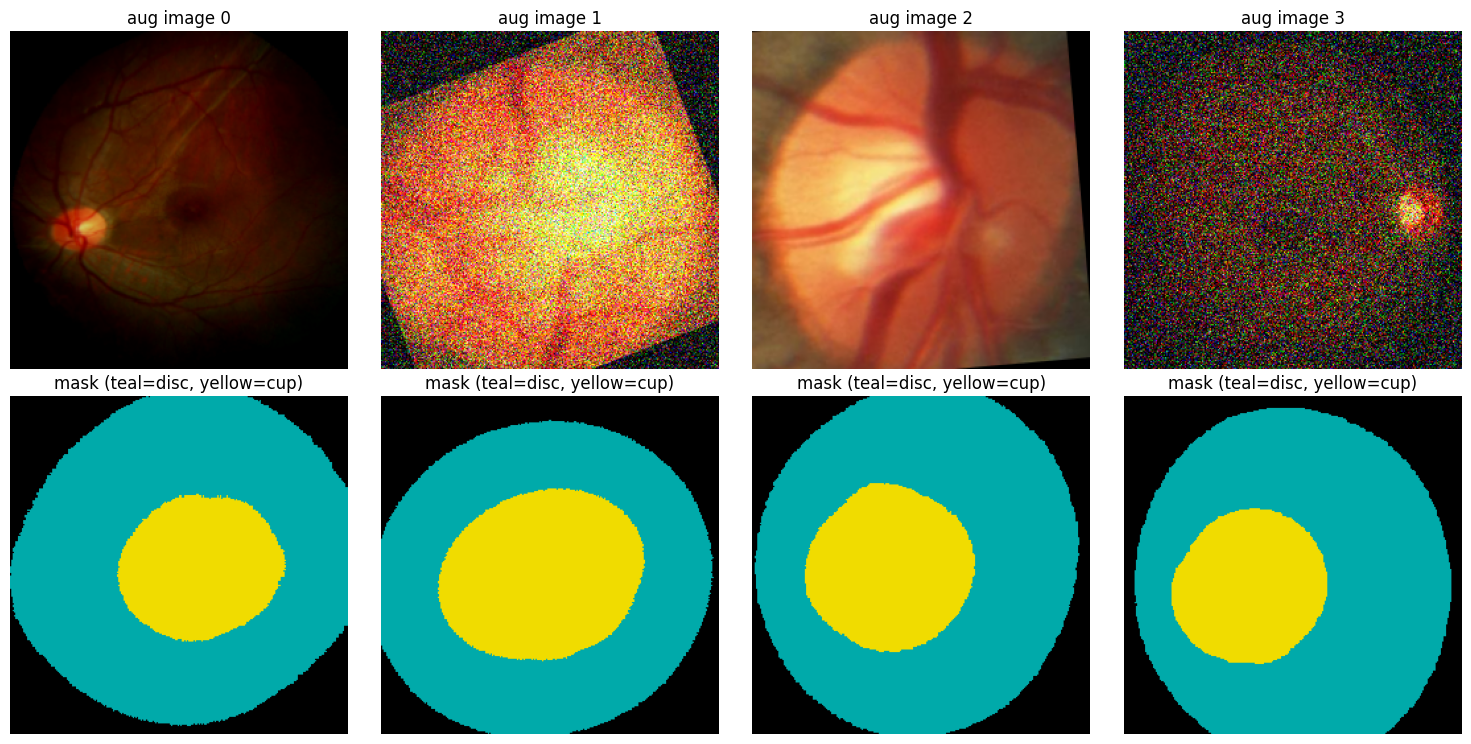

In [10]:
# ==== CELL 7 — DataLoaders + sanity check + visualize augmented samples ====
train_ds = REFUGEDataset(split_pairs["train"], train_tf)
val_ds   = REFUGEDataset(split_pairs["val"],   val_tf)
test_ds  = REFUGEDataset(split_pairs["test"],  val_tf)

train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True,
                          num_workers=cfg.NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=cfg.BATCH_SIZE, shuffle=False,
                          num_workers=cfg.NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=cfg.BATCH_SIZE, shuffle=False,
                          num_workers=cfg.NUM_WORKERS, pin_memory=True)

xb, yb = next(iter(train_loader))
print("Batch image:", tuple(xb.shape), "| mask:", tuple(yb.shape),
      "| mask classes present:", torch.unique(yb).tolist())

def denorm(t):
    img = t.permute(1,2,0).cpu().numpy()
    img = img*np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    return np.clip(img, 0, 1)

CMAP = np.array([[0,0,0],[0,170,170],[240,220,0]], dtype=np.uint8)  # bg / disc / cup
def colorize(mask):
    return CMAP[mask]

fig, ax = plt.subplots(2, 4, figsize=(15, 7.5))
for j in range(4):
    ax[0,j].imshow(denorm(xb[j])); ax[0,j].set_title(f"aug image {j}"); ax[0,j].axis("off")
    ax[1,j].imshow(colorize(yb[j].cpu().numpy())); ax[1,j].set_title("mask (teal=disc, yellow=cup)"); ax[1,j].axis("off")
plt.tight_layout(); plt.show()

In [11]:
# ==== CELL 8 — KAN building blocks (official efficient-KAN math) ====
class KANLinear(nn.Module):
    def __init__(self, in_features, out_features, grid_size=5, spline_order=3,
                 scale_noise=0.1, scale_base=1.0, scale_spline=1.0,
                 enable_standalone_scale_spline=True,
                 base_activation=nn.SiLU, grid_range=[-1, 1]):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.grid_size = grid_size
        self.spline_order = spline_order
        h = (grid_range[1] - grid_range[0]) / grid_size
        grid = ((torch.arange(-spline_order, grid_size + spline_order + 1) * h + grid_range[0])
                .expand(in_features, -1).contiguous())
        self.register_buffer("grid", grid)
        self.base_weight   = nn.Parameter(torch.Tensor(out_features, in_features))
        self.spline_weight = nn.Parameter(torch.Tensor(out_features, in_features, grid_size + spline_order))
        self.enable_standalone_scale_spline = enable_standalone_scale_spline
        if enable_standalone_scale_spline:
            self.spline_scaler = nn.Parameter(torch.Tensor(out_features, in_features))
        self.scale_noise = scale_noise; self.scale_base = scale_base; self.scale_spline = scale_spline
        self.base_activation = base_activation()
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.kaiming_uniform_(self.base_weight, a=math.sqrt(5) * self.scale_base)
        with torch.no_grad():
            noise = ((torch.rand(self.grid_size + 1, self.in_features, self.out_features) - 0.5)
                     * self.scale_noise / self.grid_size)
            self.spline_weight.data.copy_(
                (self.scale_spline if not self.enable_standalone_scale_spline else 1.0)
                * self.curve2coeff(self.grid.T[self.spline_order:-self.spline_order], noise))
            if self.enable_standalone_scale_spline:
                nn.init.kaiming_uniform_(self.spline_scaler, a=math.sqrt(5) * self.scale_spline)

    def b_splines(self, x):
        grid = self.grid
        x = x.unsqueeze(-1)
        bases = ((x >= grid[:, :-1]) & (x < grid[:, 1:])).to(x.dtype)
        for k in range(1, self.spline_order + 1):
            bases = ((x - grid[:, :-(k+1)]) / (grid[:, k:-1] - grid[:, :-(k+1)]) * bases[:, :, :-1]) \
                  + ((grid[:, k+1:] - x) / (grid[:, k+1:] - grid[:, 1:(-k)]) * bases[:, :, 1:])
        return bases.contiguous()

    def curve2coeff(self, x, y):
        A = self.b_splines(x).transpose(0, 1)
        B = y.transpose(0, 1)
        solution = torch.linalg.lstsq(A, B).solution
        return solution.permute(2, 0, 1).contiguous()

    @property
    def scaled_spline_weight(self):
        s = self.spline_scaler.unsqueeze(-1) if self.enable_standalone_scale_spline else 1.0
        return self.spline_weight * s

    def forward(self, x):
        orig = x.shape
        x = x.reshape(-1, self.in_features)
        base_out   = F.linear(self.base_activation(x), self.base_weight)
        spline_out = F.linear(self.b_splines(x).view(x.size(0), -1),
                              self.scaled_spline_weight.view(self.out_features, -1))
        return (base_out + spline_out).reshape(*orig[:-1], self.out_features)


class DW_bn_relu(nn.Module):
    """Depthwise 3x3 conv + BN + ReLU: injects local spatial context between KAN layers."""
    def __init__(self, dim):
        super().__init__()
        self.dwconv = nn.Conv2d(dim, dim, 3, 1, 1, bias=True, groups=dim)
        self.bn = nn.BatchNorm2d(dim)
        self.relu = nn.ReLU()
    def forward(self, x, H, W):
        B, N, C = x.shape
        x = x.transpose(1, 2).view(B, C, H, W)
        x = self.relu(self.bn(self.dwconv(x)))
        return x.flatten(2).transpose(1, 2)


class KANLayer(nn.Module):
    """3 KANLinear sublayers, each followed by DW_bn_relu — the official 3-sublayer block."""
    def __init__(self, in_features, hidden_features=None, out_features=None):
        super().__init__()
        hidden_features = hidden_features or in_features
        out_features = out_features or in_features
        self.fc1 = KANLinear(in_features, hidden_features)
        self.fc2 = KANLinear(hidden_features, out_features)
        self.fc3 = KANLinear(hidden_features, out_features)
        self.dwconv_1 = DW_bn_relu(hidden_features)
        self.dwconv_2 = DW_bn_relu(hidden_features)
        self.dwconv_3 = DW_bn_relu(hidden_features)
    def forward(self, x, H, W):
        B, N, C = x.shape
        x = self.dwconv_1(self.fc1(x.reshape(B*N, C)).reshape(B, N, C), H, W)
        x = self.dwconv_2(self.fc2(x.reshape(B*N, C)).reshape(B, N, C), H, W)
        x = self.dwconv_3(self.fc3(x.reshape(B*N, C)).reshape(B, N, C), H, W)
        return x


def drop_path(x, drop_prob: float = 0., training: bool = False):
    if drop_prob == 0. or not training: return x
    keep = 1 - drop_prob
    shape = (x.shape[0],) + (1,) * (x.ndim - 1)
    rnd = keep + torch.rand(shape, dtype=x.dtype, device=x.device)
    return x.div(keep) * rnd.floor()

class DropPath(nn.Module):
    def __init__(self, drop_prob=None):
        super().__init__(); self.drop_prob = drop_prob
    def forward(self, x): return drop_path(x, self.drop_prob, self.training)


class KANBlock(nn.Module):
    """Residual wrapper: x + DropPath(KANLayer(LayerNorm(x)))."""
    def __init__(self, dim, drop_path_p=0., norm_layer=nn.LayerNorm):
        super().__init__()
        self.norm2 = norm_layer(dim)
        self.drop_path = DropPath(drop_path_p) if drop_path_p > 0. else nn.Identity()
        self.layer = KANLayer(in_features=dim, hidden_features=dim)
    def forward(self, x, H, W):
        return x + self.drop_path(self.layer(self.norm2(x), H, W))

print("KAN blocks defined.")

KAN blocks defined.


In [12]:
# ==== CELL 9 — Dual-decoder U-Net with a KAN BOTTLENECK ====
# Shared plain-U-Net conv encoder (DoubleConv, 64/128/256/512) -> KAN bottleneck ->
# TWO parallel conv decoders (disc head [bg,disc], cup head [bg,cup]).
# Only the bottleneck differs from your original Y-Net (conv -> tokenized KAN).

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True))
    def forward(self, x): return self.net(x)

class UpBlock(nn.Module):
    """ConvTranspose upsample -> concat shared-encoder skip -> DoubleConv."""
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.conv = DoubleConv(out_ch + skip_ch, out_ch)
    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:               # guard against odd sizes
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        return self.conv(torch.cat([x, skip], dim=1))

class Decoder(nn.Module):
    """One decoder branch: 4 up-steps on the shared skips, then 1x1 head -> 2 channels."""
    def __init__(self, bott_ch=512, base=64, out_classes=2):
        super().__init__()
        self.up1 = UpBlock(bott_ch, base*8, base*8)   # + s4 (512)
        self.up2 = UpBlock(base*8,  base*4, base*4)   # + s3 (256)
        self.up3 = UpBlock(base*4,  base*2, base*2)   # + s2 (128)
        self.up4 = UpBlock(base*2,  base*1, base*1)   # + s1 (64)
        self.head = nn.Conv2d(base, out_classes, kernel_size=1)
    def forward(self, b, s1, s2, s3, s4):
        d = self.up1(b, s4); d = self.up2(d, s3); d = self.up3(d, s2); d = self.up4(d, s1)
        return self.head(d)

class KANBottleneck(nn.Module):
    """Tokenize the deepest feature map, run N residual KANBlocks, reshape back to a map."""
    def __init__(self, in_ch, dim=512, depth=2, drop_path_rate=0.0, norm_layer=nn.LayerNorm):
        super().__init__()
        self.proj = nn.Conv2d(in_ch, dim, kernel_size=1) if in_ch != dim else nn.Identity()
        self.norm_in = norm_layer(dim)
        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, max(depth, 1))]
        self.blocks = nn.ModuleList([KANBlock(dim, dpr[i], norm_layer) for i in range(depth)])
        self.norm_out = norm_layer(dim)
    def forward(self, x):
        x = self.proj(x)                       # B, dim, H, W
        B, C, H, W = x.shape
        t = self.norm_in(x.flatten(2).transpose(1, 2))     # B, N, dim
        for blk in self.blocks:
            t = blk(t, H, W)
        t = self.norm_out(t)
        return t.transpose(1, 2).reshape(B, C, H, W)

class DualDecoderKANUNet(nn.Module):
    def __init__(self, in_channels=3, base=64, bott_dim=512, kan_depth=2, drop_path_rate=0.0):
        super().__init__()
        self.enc1 = DoubleConv(in_channels, base)      # 64
        self.enc2 = DoubleConv(base,   base*2)          # 128
        self.enc3 = DoubleConv(base*2, base*4)          # 256
        self.enc4 = DoubleConv(base*4, base*8)          # 512
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = KANBottleneck(base*8, dim=bott_dim, depth=kan_depth,
                                        drop_path_rate=drop_path_rate)
        self.disc_decoder = Decoder(bott_ch=bott_dim, base=base, out_classes=2)  # [bg, disc]
        self.cup_decoder  = Decoder(bott_ch=bott_dim, base=base, out_classes=2)  # [bg, cup]
    def forward(self, x):
        s1 = self.enc1(x)                       # H
        s2 = self.enc2(self.pool(s1))           # H/2
        s3 = self.enc3(self.pool(s2))           # H/4
        s4 = self.enc4(self.pool(s3))           # H/8
        b  = self.bottleneck(self.pool(s4))     # H/16  (KAN)
        disc_logits = self.disc_decoder(b, s1, s2, s3, s4)
        cup_logits  = self.cup_decoder(b, s1, s2, s3, s4)
        return disc_logits, cup_logits

# build + sanity check
model = DualDecoderKANUNet(in_channels=3, base=64,
                           bott_dim=cfg.BOTT_DIM, kan_depth=cfg.KAN_DEPTH,
                           drop_path_rate=cfg.DROP_PATH).to(DEVICE)
with torch.no_grad():
    _t = torch.randn(2, 3, cfg.IMG_SIZE, cfg.IMG_SIZE, device=DEVICE)
    _d, _c = model(_t)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("disc logits:", tuple(_d.shape), "| cup logits:", tuple(_c.shape),
      "| Trainable params:", f"{n_params:,}")

disc logits: (2, 2, 256, 256) | cup logits: (2, 2, 256, 256) | Trainable params: 42,740,804


In [13]:
# ==== CELL 10 — Dual-head loss = Loss(disc) + Loss(cup) ====
# Each head is BINARY [bg, fg].  Per-head loss = W_CE*CE + W_DICE*Dice + W_FT*FocalTversky.
# Focal-Tversky (alpha<beta) penalises FALSE NEGATIVES harder -> raises cup RECALL.
class DiceLoss(nn.Module):
    def __init__(self, num_classes=2, smooth=1e-6):
        super().__init__(); self.n = num_classes; self.smooth = smooth
    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        t = F.one_hot(targets, self.n).permute(0, 3, 1, 2).float()
        dims = (0, 2, 3)
        inter = (probs * t).sum(dims); card = probs.sum(dims) + t.sum(dims)
        dice = (2*inter + self.smooth) / (card + self.smooth)
        return 1 - dice.mean()

class FocalTverskyLoss(nn.Module):
    def __init__(self, num_classes=2, alpha=0.3, beta=0.7, gamma=0.75, smooth=1e-6):
        super().__init__()
        self.n = num_classes; self.a = alpha; self.b = beta; self.g = gamma; self.smooth = smooth
    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        t = F.one_hot(targets, self.n).permute(0, 3, 1, 2).float()
        dims = (0, 2, 3)
        tp = (probs*t).sum(dims); fp = (probs*(1-t)).sum(dims); fn = ((1-probs)*t).sum(dims)
        tv = (tp + self.smooth) / (tp + self.a*fp + self.b*fn + self.smooth)
        return ((1 - tv) ** self.g).mean()

class HeadLoss(nn.Module):
    def __init__(self, cfg, class_weights, device):
        super().__init__()
        w = torch.tensor(class_weights, dtype=torch.float32, device=device)
        self.ce   = nn.CrossEntropyLoss(weight=w)
        self.dice = DiceLoss(2)
        self.ft   = FocalTverskyLoss(2, cfg.TVERSKY_ALPHA, cfg.TVERSKY_BETA, cfg.TVERSKY_GAMMA)
        self.wce, self.wdice, self.wft = cfg.W_CE, cfg.W_DICE, cfg.W_FT
    def forward(self, logits, targets):
        return self.wce*self.ce(logits, targets) + self.wdice*self.dice(logits, targets) \
             + self.wft*self.ft(logits, targets)

disc_criterion = HeadLoss(cfg, cfg.DISC_CLASS_WEIGHTS, DEVICE)
cup_criterion  = HeadLoss(cfg, cfg.CUP_CLASS_WEIGHTS,  DEVICE)

def joint_loss(disc_logits, cup_logits, mask3):
    disc_t, cup_t = split_heads(mask3)
    ld = disc_criterion(disc_logits, disc_t)
    lc = cup_criterion(cup_logits,  cup_t)
    return ld + lc, ld.detach(), lc.detach()

print(f"Dual-head loss ready:  Loss(disc) + Loss(cup)  "
      f"[each = {cfg.W_CE}*CE + {cfg.W_DICE}*Dice + {cfg.W_FT}*FocalTversky]")

Dual-head loss ready:  Loss(disc) + Loss(cup)  [each = 0.4*CE + 0.3*Dice + 0.3*FocalTversky]


In [19]:
# ==== CELL 11 — Metric suite (per-head binary metrics + 3-class fusion helper) ====
@torch.no_grad()
def binary_metrics(logits, targets, smooth=1e-6):
    """Per-class Dice (bg + fg) plus full foreground metrics for a binary head."""
    preds = torch.argmax(logits, dim=1)
    out = {}
    for c in (0, 1):                       # class 0 = bg, class 1 = foreground
        pc, tc = (preds == c), (targets == c)
        tp = (pc & tc).sum().float(); fp = (pc & ~tc).sum().float(); fn = (~pc & tc).sum().float()
        out[f"dice_{c}"] = ((2*tp + smooth) / (2*tp + fp + fn + smooth)).item()
    # detailed foreground (class 1) metrics
    pc, tc = (preds == 1), (targets == 1)
    tp = (pc & tc).sum().float(); fp = (pc & ~tc).sum().float(); fn = (~pc & tc).sum().float()
    precision = (tp + smooth) / (tp + fp + smooth)
    recall    = (tp + smooth) / (tp + fn + smooth)
    out["dice_bg"] = out["dice_0"]
    out["dice"]    = out["dice_1"]         # 'dice' stays = foreground (keeps rest of code working)
    out["iou"]       = ((tp + smooth) / (tp + fp + fn + smooth)).item()
    out["precision"] = precision.item()
    out["recall"]    = recall.item()
    out["f1"]        = ((2*precision*recall) / (precision + recall + smooth)).item()
    out["accuracy"]  = (preds == targets).float().mean().item()
    return out


def fuse_3class(disc_p, cup_p):
    """Combine two binary predictions into {0=bg,1=rim,2=cup}, enforcing cup ⊆ disc."""
    final = disc_p.copy()                       # disc (whole) -> 1
    final[(cup_p == 1) & (disc_p == 1)] = 2     # cup inside disc -> 2
    return final.astype(np.uint8)

def dice_bin(a, b, smooth=1e-6):
    a = a.astype(bool); b = b.astype(bool)
    inter = (a & b).sum()
    return (2*inter + smooth) / (a.sum() + b.sum() + smooth)

def hd95_binary(pred_bin, gt_bin):
    from scipy.ndimage import distance_transform_edt as edt
    pred_bin = pred_bin.astype(bool); gt_bin = gt_bin.astype(bool)
    if pred_bin.sum() == 0 or gt_bin.sum() == 0: return np.nan
    dt_gt = edt(~gt_bin); dt_pred = edt(~pred_bin)
    pe = pred_bin ^ ndimage.binary_erosion(pred_bin)
    ge = gt_bin   ^ ndimage.binary_erosion(gt_bin)
    d1 = dt_gt[pe]; d2 = dt_pred[ge]
    d = np.concatenate([d1, d2]) if (d1.size and d2.size) else (d1 if d1.size else d2)
    return float(np.percentile(d, 95)) if d.size else np.nan

print("Metrics ready: per-head binary Dice/IoU/Prec/Recall/F1/Acc, 3-class fusion, HD95.")

Metrics ready: per-head binary Dice/IoU/Prec/Recall/F1/Acc, 3-class fusion, HD95.


In [23]:
# ==== CELL 12 — Optimizer, scheduler, train / validate loops (dual-head) ====
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.EPOCHS, eta_min=1e-6)
scaler = GradScaler(enabled=cfg.USE_AMP)

def train_one_epoch():
    model.train()
    running = 0.0
    optimizer.zero_grad(set_to_none=True)
    for i, (imgs, masks) in enumerate(train_loader):
        imgs, masks = imgs.to(DEVICE, non_blocking=True), masks.to(DEVICE, non_blocking=True)
        with autocast(enabled=cfg.USE_AMP):
            disc_logits, cup_logits = model(imgs)
            loss, _, _ = joint_loss(disc_logits, cup_logits, masks)
            loss = loss / cfg.ACCUM_STEPS
        scaler.scale(loss).backward()
        if (i + 1) % cfg.ACCUM_STEPS == 0:
            scaler.step(optimizer); scaler.update()
            optimizer.zero_grad(set_to_none=True)
        running += loss.item() * cfg.ACCUM_STEPS
    return running / len(train_loader)

@torch.no_grad()
def evaluate(loader):
    """Average loss + SEPARATE disc/cup foreground metrics over a loader."""
    model.eval()
    keys = ["dice","dice_bg","iou","precision","recall","f1","accuracy"]
    d_agg = {k:0.0 for k in keys}; c_agg = {k:0.0 for k in keys}
    loss_sum, n = 0.0, 0
    for imgs, masks in loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        with autocast(enabled=cfg.USE_AMP):
            disc_logits, cup_logits = model(imgs)
            loss, _, _ = joint_loss(disc_logits, cup_logits, masks)
        disc_t, cup_t = split_heads(masks)
        dm = binary_metrics(disc_logits.float(), disc_t)
        cm = binary_metrics(cup_logits.float(),  cup_t)
        for k in keys: d_agg[k] += dm[k]; c_agg[k] += cm[k]
        loss_sum += loss.item(); n += 1
    for k in keys: d_agg[k] /= n; c_agg[k] /= n
    mean_fg = (d_agg["dice"] + c_agg["dice"]) / 2.0
    return {"loss":loss_sum/n, "disc":d_agg, "cup":c_agg, "mean_fg_dice":mean_fg}

print("Optimizer=AdamW | Scheduler=CosineAnnealingLR | AMP:", cfg.USE_AMP)

Optimizer=AdamW | Scheduler=CosineAnnealingLR | AMP: True


In [25]:
# ==== CELL 13 — Training loop (early stop on val mean-FG Dice = (disc_fg+cup_fg)/2) ====
history = {"train_loss":[], "val_loss":[],
           "disc_dice":[], "cup_dice":[], "mean_fg":[],
           "disc_prec":[], "disc_rec":[], "cup_prec":[], "cup_rec":[]}
best_dc, best_epoch, patience_ctr = -1.0, -1, 0
t_start = time.time()

for epoch in range(1, cfg.EPOCHS + 1):
    tr_loss = train_one_epoch()
    scheduler.step()
    v = evaluate(val_loader)

    history["train_loss"].append(tr_loss); history["val_loss"].append(v["loss"])
    history["disc_dice"].append(v["disc"]["dice"]); history["cup_dice"].append(v["cup"]["dice"])
    history["mean_fg"].append(v["mean_fg_dice"])
    history["disc_prec"].append(v["disc"]["precision"]); history["disc_rec"].append(v["disc"]["recall"])
    history["cup_prec"].append(v["cup"]["precision"]);  history["cup_rec"].append(v["cup"]["recall"])

    flag = ""
    if v["mean_fg_dice"] > best_dc:
        best_dc, best_epoch, patience_ctr = v["mean_fg_dice"], epoch, 0
        torch.save({"model": model.state_dict(), "epoch": epoch,
                    "val_mean_fg_dice": best_dc, "cfg": cfg.__dict__}, cfg.CKPT_PATH)
        flag = " -> NEW BEST (saved)"
    else:
        patience_ctr += 1

    print(f"Epoch {epoch:3d}/{cfg.EPOCHS} | train {tr_loss:.4f} | val {v['loss']:.4f} | "
          f"DISC[bg {v['disc']['dice_bg']:.3f} disc {v['disc']['dice']:.3f}] | "
          f"CUP[bg {v['cup']['dice_bg']:.3f} cup {v['cup']['dice']:.3f}] | "
          f"Mean-FG {v['mean_fg_dice']:.4f}{flag}")

    if patience_ctr >= cfg.PATIENCE:
        print(f"\nEarly stopping at epoch {epoch} (no val improvement for {cfg.PATIENCE} epochs).")
        break

print(f"\nDone in {(time.time()-t_start)/60:.1f} min | "
      f"Best val Mean-FG Dice = {best_dc:.4f} @ epoch {best_epoch}")

Epoch   1/120 | train 0.4126 | val 0.5152 | DISC[bg 0.773 disc 0.906] | CUP[bg 0.951 cup 0.776] | Mean-FG 0.8406 -> NEW BEST (saved)
Epoch   2/120 | train 0.3740 | val 0.4551 | DISC[bg 0.827 disc 0.920] | CUP[bg 0.954 cup 0.791] | Mean-FG 0.8554 -> NEW BEST (saved)
Epoch   3/120 | train 0.3633 | val 0.5342 | DISC[bg 0.804 disc 0.912] | CUP[bg 0.935 cup 0.745] | Mean-FG 0.8284
Epoch   4/120 | train 0.3562 | val 0.4495 | DISC[bg 0.823 disc 0.918] | CUP[bg 0.956 cup 0.792] | Mean-FG 0.8551
Epoch   5/120 | train 0.3481 | val 0.4479 | DISC[bg 0.849 disc 0.929] | CUP[bg 0.946 cup 0.775] | Mean-FG 0.8518
Epoch   6/120 | train 0.3363 | val 0.4369 | DISC[bg 0.844 disc 0.925] | CUP[bg 0.957 cup 0.796] | Mean-FG 0.8605 -> NEW BEST (saved)
Epoch   7/120 | train 0.3318 | val 0.4327 | DISC[bg 0.855 disc 0.927] | CUP[bg 0.956 cup 0.793] | Mean-FG 0.8601
Epoch   8/120 | train 0.3216 | val 0.4148 | DISC[bg 0.848 disc 0.927] | CUP[bg 0.958 cup 0.798] | Mean-FG 0.8625 -> NEW BEST (saved)
Epoch   9/120 | 

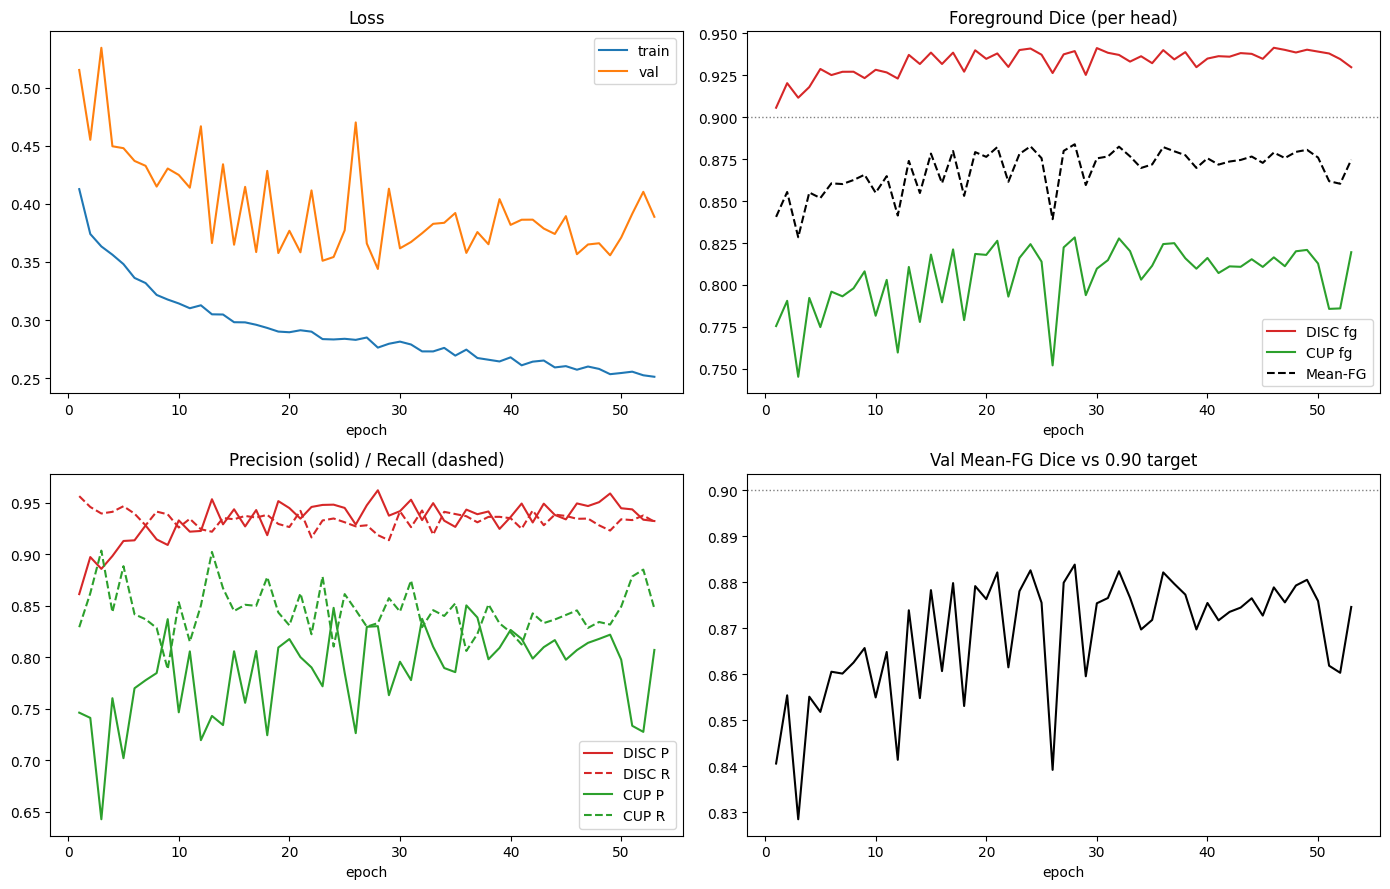

In [26]:
# ==== CELL 14 — Training curves ====
ep = range(1, len(history["train_loss"]) + 1)
fig, ax = plt.subplots(2, 2, figsize=(14, 9))

ax[0,0].plot(ep, history["train_loss"], label="train")
ax[0,0].plot(ep, history["val_loss"], label="val")
ax[0,0].set_title("Loss"); ax[0,0].legend(); ax[0,0].set_xlabel("epoch")

ax[0,1].plot(ep, history["disc_dice"], label="DISC fg", color="#d62728")
ax[0,1].plot(ep, history["cup_dice"],  label="CUP fg",  color="#2ca02c")
ax[0,1].plot(ep, history["mean_fg"], "k--", label="Mean-FG")
ax[0,1].axhline(0.90, color="gray", ls=":", lw=1)
ax[0,1].set_title("Foreground Dice (per head)"); ax[0,1].legend(); ax[0,1].set_xlabel("epoch")

ax[1,0].plot(ep, history["disc_prec"], color="#d62728", label="DISC P")
ax[1,0].plot(ep, history["disc_rec"],  color="#d62728", ls="--", label="DISC R")
ax[1,0].plot(ep, history["cup_prec"],  color="#2ca02c", label="CUP P")
ax[1,0].plot(ep, history["cup_rec"],   color="#2ca02c", ls="--", label="CUP R")
ax[1,0].set_title("Precision (solid) / Recall (dashed)"); ax[1,0].legend(); ax[1,0].set_xlabel("epoch")

ax[1,1].plot(ep, history["mean_fg"], "k-")
ax[1,1].axhline(0.90, color="gray", ls=":", lw=1)
ax[1,1].set_title("Val Mean-FG Dice vs 0.90 target"); ax[1,1].set_xlabel("epoch")

plt.tight_layout(); plt.savefig(os.path.join(cfg.OUT_DIR, "training_curves.png"), dpi=120); plt.show()

In [27]:
# ==== CELL 15 — Anatomical post-processing (largest component + cup inside disc) ====
def keep_largest(binary):
    if binary.sum() == 0: return binary
    lab, n = ndimage.label(binary)
    if n <= 1: return binary
    sizes = ndimage.sum(np.ones_like(lab), lab, range(1, n + 1))
    return lab == (int(np.argmax(sizes)) + 1)

def postprocess_fused(fused):
    """fused: HxW int in {0,1,2} -> cleaned HxW int (rim=1, cup=2), cup forced inside disc."""
    disc = keep_largest(fused >= 1)
    cup  = keep_largest(fused == 2)
    disc_full = ndimage.binary_fill_holes(disc | cup)
    cup = cup & disc_full
    res = np.zeros_like(fused)
    res[disc_full] = 1
    res[cup] = 2
    return res.astype(np.uint8)

print("Post-processing ready.")

Post-processing ready.


In [28]:
# ==== CELL 16 — Test-Time Augmentation (average softmax over flips, per head) ====
@torch.no_grad()
def predict_head_probs(imgs, use_tta=True):
    """Return averaged softmax probs for BOTH heads: (disc_probs, cup_probs), each (B,2,H,W)."""
    model.eval()
    flips = [lambda t: t,
             lambda t: torch.flip(t, dims=[3]),
             lambda t: torch.flip(t, dims=[2]),
             lambda t: torch.flip(t, dims=[2, 3])]
    ops = flips if use_tta else flips[:1]
    dp = 0; cp = 0
    for f in ops:
        with autocast(enabled=cfg.USE_AMP):
            dl, cl = model(f(imgs))
        dp = dp + f(F.softmax(dl.float(), dim=1))
        cp = cp + f(F.softmax(cl.float(), dim=1))
    return dp/len(ops), cp/len(ops)

print("TTA inference ready (", 4 if cfg.USE_TTA else 1, "views ).")

TTA inference ready ( 4 views ).


In [30]:
# ==== CELL 17 — Final test evaluation: SEPARATE pipelines + fused 3-class vs 0.90 ====
ckpt = torch.load(cfg.CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model"])
print(f"Loaded best checkpoint from epoch {ckpt['epoch']} (val Mean-FG={ckpt['val_mean_fg_dice']:.4f})\n")

def evaluate_test(use_tta, use_pp):
    keys = ["dice","iou","precision","recall","f1","accuracy"]
    d_agg = {k:0.0 for k in keys}; c_agg = {k:0.0 for k in keys}
    rim_d, cup_d, wdisc_d = [], [], []
    hd_rim, hd_cup = [], []
    n = 0
    for imgs, masks in test_loader:
        imgs = imgs.to(DEVICE)
        dprob, cprob = predict_head_probs(imgs, use_tta=use_tta)
        disc_p_b = dprob.argmax(1).cpu().numpy()   # (B,H,W) whole-disc binary
        cup_p_b  = cprob.argmax(1).cpu().numpy()   # (B,H,W) cup binary
        m_np = masks.numpy()                       # 3-class GT
        for b in range(disc_p_b.shape[0]):
            # ----- separate-pipeline metrics (the deliverable format) -----
            dt = torch.from_numpy((m_np[b] > 0).astype(np.int64))[None]
            ct = torch.from_numpy((m_np[b] == 2).astype(np.int64))[None]
            dpb = torch.from_numpy(disc_p_b[b].astype(np.int64))[None]
            cpb = torch.from_numpy(cup_p_b[b].astype(np.int64))[None]
            dm = binary_metrics(F.one_hot(dpb, 2).permute(0,3,1,2).float(), dt)
            cm = binary_metrics(F.one_hot(cpb, 2).permute(0,3,1,2).float(), ct)
            for k in keys: d_agg[k] += dm[k]; c_agg[k] += cm[k]
            # ----- fused 3-class (cup inside disc) -> rim + cup clinical metric -----
            fused = fuse_3class(disc_p_b[b], cup_p_b[b])
            if use_pp: fused = postprocess_fused(fused)
            gt = m_np[b]
            rim_d.append(dice_bin(fused == 1, gt == 1))       # RIM Dice (clinical)
            cup_d.append(dice_bin(fused == 2, gt == 2))       # CUP Dice
            wdisc_d.append(dice_bin(fused >= 1, gt >= 1))     # WHOLE-disc Dice
            hd_rim.append(hd95_binary(fused == 1, gt == 1))
            hd_cup.append(hd95_binary(fused == 2, gt == 2))
            n += 1
    for k in keys: d_agg[k] /= n; c_agg[k] /= n
    fused_stats = {
        "rim_dice": float(np.mean(rim_d)),
        "cup_dice": float(np.mean(cup_d)),
        "wdisc_dice": float(np.mean(wdisc_d)),
        "mean_rim_cup": float((np.mean(rim_d)+np.mean(cup_d))/2),
        "mean_wdisc_cup": float((np.mean(wdisc_d)+np.mean(cup_d))/2),
        "hd95_rim": float(np.nanmean(hd_rim)), "hd95_cup": float(np.nanmean(hd_cup)),
    }
    return d_agg, c_agg, fused_stats

settings = [("Raw", False, False)]
if cfg.USE_TTA: settings.append(("+TTA", True, False))
if cfg.USE_TTA and cfg.USE_POSTPROC: settings.append(("+TTA +PostProc", True, True))
elif cfg.USE_POSTPROC: settings.append(("+PostProc", False, True))

results = {}
print("=== SEPARATE PIPELINES (foreground Dice) — the deliverable format ===")
print(f"{'Setting':16s} | {'DISC fg':>8s} {'CUP fg':>7s} {'Mean-FG':>8s}")
print("-"*48)
for name, tta, pp in settings:
    d_agg, c_agg, fused = evaluate_test(tta, pp)
    results[name] = (d_agg, c_agg, fused)
    mean_fg = (d_agg["dice"] + c_agg["dice"]) / 2
    print(f"{name:16s} | {d_agg['dice']:8.4f} {c_agg['dice']:7.4f} {mean_fg:8.4f}")

best_name = settings[-1][0]
d_agg, c_agg, fused = results[best_name]
print(f"\n=== Full per-pipeline metrics ({best_name}) ===")
print(f"{'Pipeline':14s} {'Dice':>7s} {'IoU':>7s} {'Prec':>7s} {'Recall':>7s} {'F1':>7s} {'Acc':>7s}")
for nm, agg in [("DISC [bg,disc]", d_agg), ("CUP [bg,cup]", c_agg)]:
    print(f"{nm:14s} {agg['dice']:7.4f} {agg['iou']:7.4f} {agg['precision']:7.4f} "
          f"{agg['recall']:7.4f} {agg['f1']:7.4f} {agg['accuracy']:7.4f}")

print(f"\n=== Fused 3-class ({best_name}, cup inside disc) — the 0.90 target metrics ===")
print(f"  Whole-disc Dice : {fused['wdisc_dice']:.4f}   (comparable to Y-Net's disc head)")
print(f"  RIM Dice        : {fused['rim_dice']:.4f}   (clinical; comparable to old W-Net rim)")
print(f"  CUP Dice        : {fused['cup_dice']:.4f}")


import csv
with open(os.path.join(cfg.OUT_DIR, "test_metrics.csv"), "w", newline="") as fcsv:
    w = csv.writer(fcsv)
    w.writerow(["setting","disc_fg_dice","cup_fg_dice","mean_fg",
                "wdisc_dice","rim_dice","cup_dice","mean_wdisc_cup","mean_rim_cup"])
    for nm,(da,ca,fu) in results.items():
        w.writerow([nm, da['dice'], ca['dice'], (da['dice']+ca['dice'])/2,
                    fu['wdisc_dice'], fu['rim_dice'], fu['cup_dice'],
                    fu['mean_wdisc_cup'], fu['mean_rim_cup']])
print("\nSaved:", os.path.join(cfg.OUT_DIR, "test_metrics.csv"))

Loaded best checkpoint from epoch 28 (val Mean-FG=0.8838)

=== SEPARATE PIPELINES (foreground Dice) — the deliverable format ===
Setting          |  DISC fg  CUP fg  Mean-FG
------------------------------------------------
Raw              |   0.9370  0.8049   0.8710
+TTA             |   0.9374  0.8083   0.8729
+TTA +PostProc   |   0.9374  0.8083   0.8729

=== Full per-pipeline metrics (+TTA +PostProc) ===
Pipeline          Dice     IoU    Prec  Recall      F1     Acc
DISC [bg,disc]  0.9374  0.8848  0.9439  0.9340  0.9374  0.9196
CUP [bg,cup]    0.8083  0.6881  0.7948  0.8653  0.8083  0.9337

=== Fused 3-class (+TTA +PostProc, cup inside disc) — the 0.90 target metrics ===
  Whole-disc Dice : 0.9374   (comparable to Y-Net's disc head)
  RIM Dice        : 0.8437   (clinical; comparable to old W-Net rim)
  CUP Dice        : 0.8083

Saved: /kaggle/working/test_metrics.csv


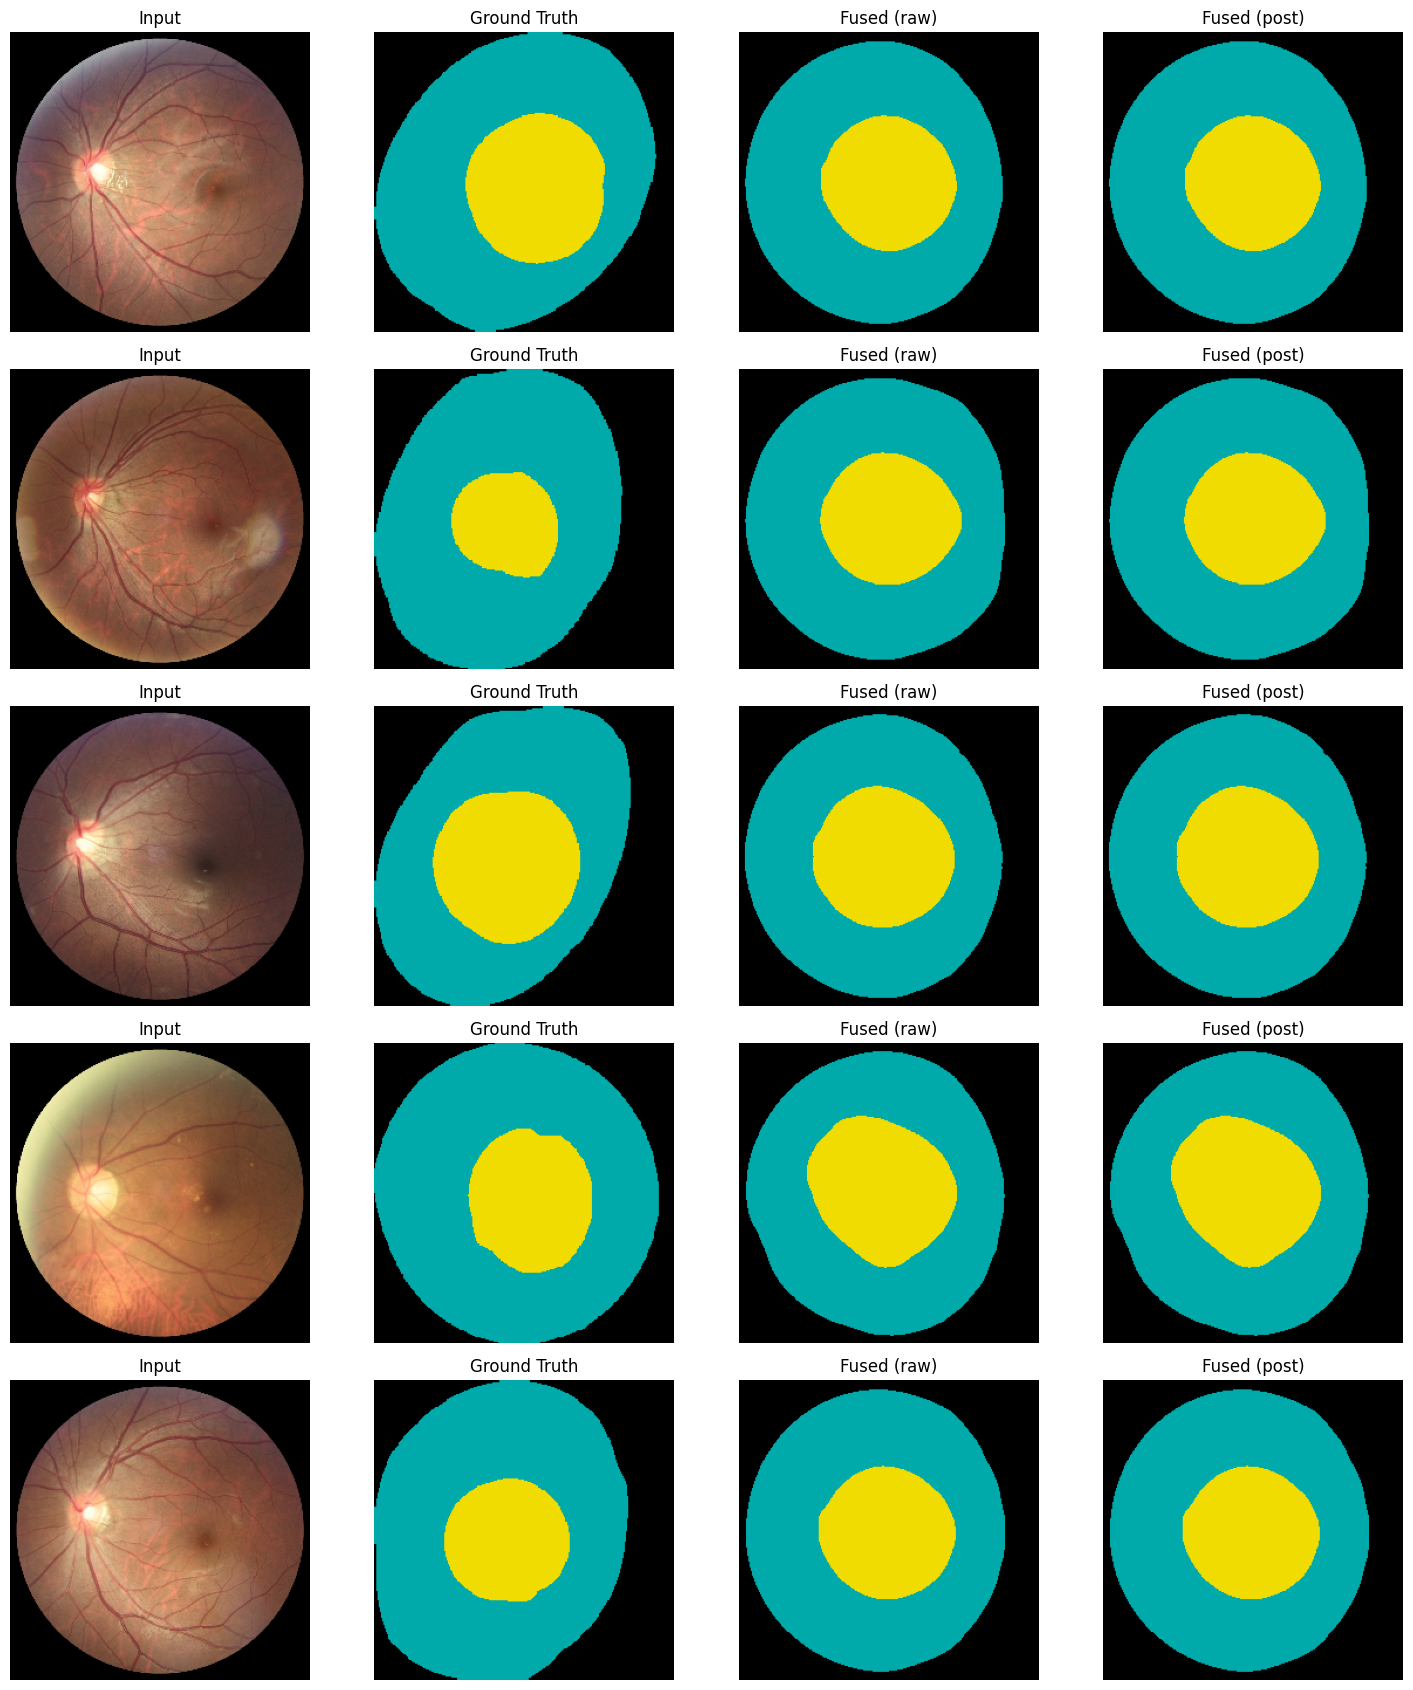

teal = optic disc/rim, yellow = optic cup


In [33]:
# ==== CELL 18 — Qualitative predictions (Input / GT / Fused pred / Post-processed) ====
model.eval()
n_show = 5; shown = 0
fig, ax = plt.subplots(n_show, 4, figsize=(15, 3.4*n_show))
for imgs, masks in test_loader:
    imgs_d = imgs.to(DEVICE)
    dprob, cprob = predict_head_probs(imgs_d, use_tta=cfg.USE_TTA)
    disc_p_b = dprob.argmax(1).cpu().numpy(); cup_p_b = cprob.argmax(1).cpu().numpy()
    for b in range(imgs.shape[0]):
        if shown >= n_show: break
        fused = fuse_3class(disc_p_b[b], cup_p_b[b]); pp = postprocess_fused(fused)
        ax[shown,0].imshow(denorm(imgs[b]));            ax[shown,0].set_title("Input");        ax[shown,0].axis("off")
        ax[shown,1].imshow(colorize(masks[b].numpy())); ax[shown,1].set_title("Ground Truth"); ax[shown,1].axis("off")
        ax[shown,2].imshow(colorize(fused));            ax[shown,2].set_title("Fused (raw)");   ax[shown,2].axis("off")
        ax[shown,3].imshow(colorize(pp));               ax[shown,3].set_title("Fused (post)");  ax[shown,3].axis("off")
        shown += 1
    if shown >= n_show: break
plt.tight_layout(); plt.savefig(os.path.join(cfg.OUT_DIR, "qualitative_predictions.png"), dpi=120); plt.show()
print("teal = optic disc/rim, yellow = optic cup")

In [34]:
# ==== CELL 19 — Run summary ====
print("="*66)
print(" DUAL-DECODER U-NET + KAN BOTTLENECK — 3-class REFUGE — RUN SUMMARY")
print("="*66)
print(f" Image size          : {cfg.IMG_SIZE}x{cfg.IMG_SIZE}")
print(f" KAN bottleneck      : dim={cfg.BOTT_DIM}, depth={cfg.KAN_DEPTH}")
print(f" Params              : {sum(p.numel() for p in model.parameters()):,}")
print(f" Best val Mean-FG    : {best_dc:.4f} @ epoch {best_epoch}")
bn = settings[-1][0]; da, ca, fu = results[bn]
print(f" Test DISC fg Dice   : {da['dice']:.4f}")
print(f" Test CUP  fg Dice   : {ca['dice']:.4f}")
print(f" Test Mean-FG (D+C)  : {(da['dice']+ca['dice'])/2:.4f}   [{bn}]")
print("-"*66)
print(f" Fused whole-disc+cup: {fu['mean_wdisc_cup']:.4f}  "
      + ("REACHED" if fu['mean_wdisc_cup']>=0.90 else f"{0.90-fu['mean_wdisc_cup']:+.4f} to go"))
print(f" Fused rim+cup (clin): {fu['mean_rim_cup']:.4f}  "
      + ("REACHED" if fu['mean_rim_cup']>=0.90 else f"{0.90-fu['mean_rim_cup']:+.4f} to go"))
print("="*66)
print(" Artifacts saved to:", cfg.OUT_DIR)
print("   kan_ynet_refuge_best.pth, training_curves.png,")
print("   qualitative_predictions.png, test_metrics.csv")
print("="*66)
print("\nIf CUP is still the ceiling, next levers (same as before): raise CUP_CLASS_WEIGHTS")
print("to 2.0-2.5, bump TVERSKY_BETA to 0.8, increase IMG_SIZE to 384, or add a KANBlock")
print("(KAN_DEPTH=3). You can also feed disc-head features into the cup decoder for coupling.")

 DUAL-DECODER U-NET + KAN BOTTLENECK — 3-class REFUGE — RUN SUMMARY
 Image size          : 256x256
 KAN bottleneck      : dim=512, depth=2
 Params              : 42,740,804
 Best val Mean-FG    : 0.8838 @ epoch 28
 Test DISC fg Dice   : 0.9374
 Test CUP  fg Dice   : 0.8083
 Test Mean-FG (D+C)  : 0.8729   [+TTA +PostProc]
------------------------------------------------------------------
 Fused whole-disc+cup: 0.8729  +0.0271 to go
 Fused rim+cup (clin): 0.8260  +0.0740 to go
 Artifacts saved to: /kaggle/working
   kan_ynet_refuge_best.pth, training_curves.png,
   qualitative_predictions.png, test_metrics.csv

If CUP is still the ceiling, next levers (same as before): raise CUP_CLASS_WEIGHTS
to 2.0-2.5, bump TVERSKY_BETA to 0.8, increase IMG_SIZE to 384, or add a KANBlock
(KAN_DEPTH=3). You can also feed disc-head features into the cup decoder for coupling.
